# Train Test Splits, Cross Validation, and Linear Regression

![Lregressions.png](Assets/linearRegr.png)

## Introduction

We will be working with a data set based on [housing prices in Ames, Iowa](https://www.kaggle.com/c/house-prices-advanced-regression-techniques). It was compiled for educational use to be a modernized and expanded alternative to the well-known Boston Housing dataset. This version of the data set has had some missing values filled for convenience.

There are an extensive number of features, so they've been described in the table below.

### Predictor

* SalePrice: The property's sale price in dollars.


### Features

<table>
  <tbody>    
    <tr valign="top">
      <td valign="top">
        <ul>
          <li>MoSold: Month Sold</li>
          <li>YrSold: Year Sold</li><br>
          
          <li>SaleType: Type of sale</li>
          <li>SaleCondition: Condition of sale</li><br>

          <li>MSSubClass: The building class</li>
          <li>MSZoning: The general zoning classification</li><br>

          <li>Neighborhood: Physical locations within Ames city limits</li>
          <li>Street: Type of road access</li>
          <li>Alley: Type of alley access</li><br>

          <li>LotArea: Lot size in square feet</li>
          <li>LotConfig: Lot configuration</li>
          <li>LotFrontage: Linear feet of street connected to property</li>
          <li>LotShape: General shape of property</li><br>

          <li>LandSlope: Slope of property</li>
          <li>LandContour: Flatness of the property</li><br>

          <li>YearBuilt: Original construction date</li>
          <li>YearRemodAdd: Remodel date</li>
          <li>OverallQual: Overall material and finish quality</li>
          <li>OverallCond: Overall condition rating</li><br>

          <li>Utilities: Type of utilities available</li>
          <li>Foundation: Type of foundation</li>
          <li>Functional: Home functionality rating</li><br>

          <li>BldgType: Type of dwelling</li>
          <li>HouseStyle: Style of dwelling</li><br>
          
          <li>1stFlrSF: First Floor square feet</li>
          <li>2ndFlrSF: Second floor square feet</li>
          <li>LowQualFinSF: Low quality finished square feet (all floors)</li>
          <li>GrLivArea: Above grade (ground) living area square feet</li>
          <li>TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)</li><br>

          <li>Condition1: Proximity to main road or railroad</li>
          <li>Condition2: Proximity to main road or railroad (if a second is present)</li><br>
          
          <li>RoofStyle: Type of roof</li>
          <li>RoofMatl: Roof material</li><br>

          <li>ExterQual: Exterior material quality</li>
          <li>ExterCond: Present condition of the material on the exterior</li>
          <li>Exterior1st: Exterior covering on house</li>
          <li>Exterior2nd: Exterior covering on house (if more than one material)</li><br><br>
          
        </ul>
      </td>
      
      <td valign="top">
        <ul>
          <li>MasVnrType: Masonry veneer type</li>
          <li>MasVnrArea: Masonry veneer area in square feet</li><br>
          
          <li>WoodDeckSF: Wood deck area in square feet</li>
          <li>OpenPorchSF: Open porch area in square feet</li>
          <li>EnclosedPorch: Enclosed porch area in square feet</li>
          <li>3SsnPorch: Three season porch area in square feet</li>
          <li>ScreenPorch: Screen porch area in square feet</li><br>

          <li>PoolArea: Pool area in square feet</li>
          <li>PoolQC: Pool quality</li>
          <li>Fence: Fence quality</li>
          <li>PavedDrive: Paved driveway</li><br>

          <li>GarageType: Garage location</li>
          <li>GarageYrBlt: Year garage was built</li>
          <li>GarageFinish: Interior finish of the garage</li>
          <li>GarageCars: Size of garage in car capacity</li>
          <li>GarageArea: Size of garage in square feet</li>
          <li>GarageQual: Garage quality</li>
          <li>GarageCond: Garage condition</li><br>

          <li>Heating: Type of heating</li>
          <li>HeatingQC: Heating quality and condition</li>
          <li>CentralAir: Central air conditioning</li>
          <li>Electrical: Electrical system</li><br>
          
          <li>FullBath: Full bathrooms above grade</li>
          <li>HalfBath: Half baths above grade</li><br>
          
          <li>BedroomAbvGr: Number of bedrooms above basement level</li><br>
          
          <li>KitchenAbvGr: Number of kitchens</li>
          <li>KitchenQual: Kitchen quality</li><br>
          
          <li>Fireplaces: Number of fireplaces</li>
          <li>FireplaceQu: Fireplace quality</li><br>
          
          <li>MiscFeature: Miscellaneous feature not covered in other categories</li>
          <li>MiscVal: Value of miscellaneous feature</li><br>
          
          <li>BsmtQual: Height of the basement</li>
          <li>BsmtCond: General condition of the basement</li>
          <li>BsmtExposure: Walkout or garden level basement walls</li>
          <li>BsmtFinType1: Quality of basement finished area</li>
          <li>BsmtFinSF1: Type 1 finished square feet</li>
          <li>BsmtFinType2: Quality of second finished area (if present)</li>
          <li>BsmtFinSF2: Type 2 finished square feet</li>
          <li>BsmtUnfSF: Unfinished square feet of basement area</li>
          <li>BsmtFullBath: Basement full bathrooms</li>
          <li>BsmtHalfBath: Basement half bathrooms</li>
          <li>TotalBsmtSF: Total square feet of basement area</li>
        </ul>
      </td>
    </tr>
    
  </tbody>
</table>


In [3]:
from __future__ import print_function
import os
data_path = [  'data']

#from sklearnex import patch_sklearn
#patch_sklearn()

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler


## Question 1

* Import the data using Pandas and examine the shape. There are 79 feature columns plus the predictor, the sale price (`SalePrice`).
* There are three different types: integers (`int64`), floats (`float64`), and strings (`object`, categoricals). Examine how many there are of each data type.

In [4]:
# prompt: import pandas as pd
# import numpy as np
# # Import the data using the file path
# filepath = os.sep.join(data_path + ['Ames_Housing_Sales.csv'])
# data = pd.read_csv(filepath, sep=',')
# print(data.shape) ...change the code to load both the train and test csv files uploaded but into a single csv merge ...fix this error also ...make it simple

import pandas as pd

# Load the training and test data
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Merge the dataframes
data = pd.concat([train_df, test_df], ignore_index=True)

# Print the shape of the merged dataframe
print(data.shape)

# Examine data types
print(data.dtypes.value_counts())

(2919, 81)
object     43
int64      26
float64    12
Name: count, dtype: int64


In [5]:
data.dtypes.value_counts()

object     43
int64      26
float64    12
Name: count, dtype: int64

## Question 2

As discussed in the lecture, a significant challenge, particularly when dealing with data that have many columns, is ensuring each column gets encoded correctly.

This is particularly true with data columns that are ordered categoricals (ordinals) vs unordered categoricals. Unordered categoricals should be one-hot encoded, however this can significantly increase the number of features and creates features that are highly correlated with each other.

Determine how many total features would be present, relative to what currently exists, if all string (object) features are one-hot encoded. Recall that the total number of one-hot encoded columns is `n-1`, where `n` is the number of categories.

In [6]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [7]:
# Select the object (string) columns
mask = data.dtypes == object
print(mask)

Id               False
MSSubClass       False
MSZoning          True
LotFrontage      False
LotArea          False
                 ...  
MoSold           False
YrSold           False
SaleType          True
SaleCondition     True
SalePrice        False
Length: 81, dtype: bool


In [8]:

categorical_cols = data.columns[mask]

In [9]:
# prompt: # Select the object (string) columns
# mask = data.dtypes == object categorical_cols = data.columns[mask] generate the meaning of it

This code snippet is performing the following actions:

1.  `mask = data.dtypes == object`: It creates a boolean mask. For each column in the DataFrame `data`, it checks if the data type (`dtype`) is 'object'. The result is a Series of boolean values, where `True` indicates the column's dtype is 'object' (which typically represents strings or mixed types in Pandas), and `False` otherwise.

2.  `print(mask)`: This line prints the generated boolean mask to the console.

3.  `categorical_cols = data.columns[mask]`: It uses the boolean mask created in the previous step to select the column names from `data.columns`. This results in a Pandas Index object containing the names of all columns in the DataFrame `data` that have an 'object' data type. These columns are assumed to be categorical columns (specifically, those stored as strings).

In essence, this code is identifying and extracting the names of the columns in the DataFrame `data` that are currently stored as 'object' data types, which are often considered categorical features.

SyntaxError: unterminated string literal (detected at line 6) (1679820988.py, line 6)

In [ ]:
print(categorical_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [ ]:
# Determine how many extra columns would be created
num_ohc_cols = (data[categorical_cols]
                .apply(lambda x: x.nunique())
                .sort_values(ascending=False))


# No need to encode if there is only one value
small_num_ohc_cols = num_ohc_cols.loc[num_ohc_cols>1]

# Number of one-hot columns is one less than the number of categories
small_num_ohc_cols -= 1

# This is 215 columns, assuming the original ones are dropped.
# This is quite a few extra columns!
small_num_ohc_cols.sum()

np.int64(208)

## Question 3

Let's create a new data set where all of the above categorical features will be one-hot encoded. We can fit this data and see how it affects the results.

* Used the dataframe `.copy()` method to create a completely separate copy of the dataframe for one-hot encoding
* On this new dataframe, one-hot encode each of the appropriate columns and add it back to the dataframe. Be sure to drop the original column.
* For the data that are not one-hot encoded, drop the columns that are string categoricals.

For the first step, numerically encoding the string categoricals, either Scikit-learn;s `LabelEncoder` or `DictVectorizer` can be used. However, the former is probably easier since it doesn't require specifying a numerical value for each category, and we are going to one-hot encode all of the numerical values anyway. (Can you think of a time when `DictVectorizer` might be preferred?)

In [ ]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
# Copy of the data
data_ohc = data.copy()
# The encoders
le = LabelEncoder()
ohc = OneHotEncoder()
for col in num_ohc_cols.index:
    # Integer encode the string categories
    dat = le.fit_transform(data_ohc[col]).astype(int)
    # Remove the original column from the dataframe
    data_ohc = data_ohc.drop(col, axis=1)
    # One hot encode the data--this returns a sparse array
    new_dat = ohc.fit_transform(dat.reshape(-1,1))
    # Create unique column names
    n_cols = new_dat.shape[1]
    col_names = ['_'.join([col, str(x)]) for x in range(n_cols)]
    # Create the new dataframe
    new_df = pd.DataFrame(new_dat.toarray(),
                          index=data_ohc.index,
                          columns=col_names)
    # Append the new data to the dataframe
    data_ohc = pd.concat([data_ohc, new_df], axis=1)

In [ ]:
# Column difference is as calculated above
data_ohc.shape[1] - data.shape[1]

231

In [ ]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [ ]:
data_ohc.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,Utilities_0,Utilities_1,Utilities_2,Alley_0,Alley_1,Alley_2,Street_0,Street_1,CentralAir_0,CentralAir_1
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [ ]:
data['Utilities'].head(5)

,Utilities
0,AllPub
1,AllPub
2,AllPub
3,AllPub
4,AllPub


In [ ]:
# prompt: data['Utilities'].head(5) ..unique values only

data['Utilities'].unique()

array(['AllPub', 'NoSeWa', nan], dtype=object)

In [ ]:
print(data.shape[1])

# Remove the string columns from the dataframe
data = data.drop(num_ohc_cols.index, axis=1)

print(data.shape[1])

81
38


## Question 4

* Create train and test splits of both data sets. To ensure the data gets split the same way, use the same `random_state` in each of the two splits.
* For each data set, fit a basic linear regression model on the training data.
* Calculate the mean squared error on both the train and test sets for the respective models. Which model produces smaller error on the test data and why?

In [ ]:
# prompt: X_train, X_test, y_train, y_test = train_test_split(X_data, y_data,
#                                                     test_size=0.3, random_state=42)  ...what this code means

This line of code uses the `train_test_split` function from the `sklearn.model_selection` module to split your data into training and testing sets for machine learning purposes. Let's break down the arguments and variables:

-   `X_data`: This is the DataFrame or NumPy array containing your feature data (the independent variables).
-   `y_data`: This is the Series or NumPy array containing your target variable (the dependent variable you want to predict).
-   `test_size=0.3`: This specifies the proportion of the data that should be allocated to the test set. In this case, 30% of the data will be used for testing, and the remaining 70% will be used for training.
-   `random_state=42`: This is used to seed the random number generator. Providing an integer value here ensures that the split is reproducible. If you run this code multiple times with the same `random_state`, you will get the exact same train and test splits. This is crucial for debugging and comparing different models consistently.

The function returns four variables:

-   `X_train`: The feature data for the training set (70% of `X_data`).
-   `X_test`: The feature data for the testing set (30% of `X_data`).
-   `y_train`: The target variable for the training set (corresponding to `X_train`).
-   `y_test`: The target variable for the testing set (corresponding to `X_test`).

In summary, this line splits your original feature data (`X_data`) and target data (`y_data`) into two sets: one for training your machine learning model and one for evaluating its performance on unseen data. The split is done randomly but reproducibly due to the `random_state`.

In [ ]:
from sklearn.model_selection import train_test_split
y_col = 'SalePrice'

# Split the data that is not one-hot encoded
feature_cols = [x for x in data.columns if x != y_col]
X_data = data[feature_cols]
y_data = data[y_col]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data,
                                                    test_size=0.3, random_state=42)
# Split the data that is one-hot encoded
feature_cols = [x for x in data_ohc.columns if x != y_col]
X_data_ohc = data_ohc[feature_cols]
y_data_ohc = data_ohc[y_col]

X_train_ohc, X_test_ohc, y_train_ohc, y_test_ohc = train_test_split(X_data_ohc, y_data_ohc,
                                                    test_size=0.3, random_state=42)

In [ ]:
# Compare the indices to ensure they are identical
(X_train_ohc.index == X_train.index).all()

np.True_

In [ ]:
# prompt: Input X contains NaN ...fix this error in the code   from sklearn.linear_model import LinearRegression
# LR = LinearRegression()
# # Storage for error values
# error_df = list()
# # Data that have not been one-hot encoded
# LR = LR.fit(X_train.values, y_train.values)
# y_train_pred = LR.predict(X_train.values)
# y_test_pred = LR.predict(X_test.values)
# error_df.append(pd.Series({'train': mean_squared_error(y_train, y_train_pred),
#                            'test' : mean_squared_error(y_test,  y_test_pred)},
#                            name='no enc'))
# # Data that have been one-hot encoded
# LR = LinearRegression()
# LR = LR.fit(X_train_ohc.values, y_train_ohc.values)
# y_train_ohc_pred = LR.predict(X_train_ohc.values)
# y_test_ohc_pred = LR.predict(X_test_ohc.values)
# error_df.append(pd.Series({'train': mean_squared_error(y_train_ohc, y_train_ohc_pred),
#                            'test' : mean_squared_error(y_test_ohc,  y_test_ohc_pred)},
#                           name='one-hot enc'))
# # Assemble the results
# error_df = pd.concat(error_df, axis=1)
# error_df ...fix this error as wellInput y contains NaN
from sklearn.metrics import mean_squared_error
# Check for and handle NaNs in the data
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())
y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_test.mean())

X_train_ohc = X_train_ohc.fillna(X_train_ohc.mean())
X_test_ohc = X_test_ohc.fillna(X_test_ohc.mean())
y_train_ohc = y_train_ohc.fillna(y_train_ohc.mean())
y_test_ohc = y_test_ohc.fillna(y_test_ohc.mean())

from sklearn.linear_model import LinearRegression
LR = LinearRegression()
# Storage for error values
error_df = list()
# Data that have not been one-hot encoded
LR = LR.fit(X_train.values, y_train.values)
y_train_pred = LR.predict(X_train.values)
y_test_pred = LR.predict(X_test.values)
error_df.append(pd.Series({'train': mean_squared_error(y_train, y_train_pred),
                           'test' : mean_squared_error(y_test,  y_test_pred)},
                           name='no enc'))
# Data that have been one-hot encoded
LR = LinearRegression()
LR = LR.fit(X_train_ohc.values, y_train_ohc.values)
y_train_ohc_pred = LR.predict(X_train_ohc.values)
y_test_ohc_pred = LR.predict(X_test_ohc.values)
error_df.append(pd.Series({'train': mean_squared_error(y_train_ohc, y_train_ohc_pred),
                           'test' : mean_squared_error(y_test_ohc,  y_test_ohc_pred)},
                          name='one-hot enc'))
# Assemble the results
error_df = pd.concat(error_df, axis=1)
error_df


,no enc,one-hot enc
train,1.753526e+09,1.433563e+09
test,2.056876e+09,2.104297e+09


Note that the error values on the one-hot encoded data are very different for the train and test data. In particular, the errors on the test data are much higher. Based on the lecture, this is because the one-hot encoded model is overfitting the data. We will learn how to deal with issues like this in the next lesson.

## Question 5

For each of the data sets (one-hot encoded and not encoded):

* Scale the all the non-hot encoded values using one of the following: `StandardScaler`, `MinMaxScaler`, `MaxAbsScaler`.
* Compare the error calculated on the test sets

Be sure to calculate the skew (to decide if a transformation should be done) and fit the scaler on *ONLY* the training data, but then apply it to both the train and test data identically.

In [ ]:
# Mute the setting wtih a copy warnings
pd.options.mode.chained_assignment = None

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
scalers = {'standard': StandardScaler(),
           'minmax': MinMaxScaler(),
           'maxabs': MaxAbsScaler()}

training_test_sets = {
    'not_encoded': (X_train, y_train, X_test, y_test),
    'one_hot_encoded': (X_train_ohc, y_train_ohc, X_test_ohc, y_test_ohc)}


# Get the list of float columns, and the float data
# so that we don't scale something we already scaled.
# We're supposed to scale the original data each time
mask = X_train.dtypes == float
float_columns = X_train.columns[mask]

# iterate over all possible combinations and get the errors
errors = {}
for encoding_label, (_X_train, _y_train, _X_test, _y_test) in training_test_sets.items():
    for scaler_label, scaler in scalers.items():
        trainingset = _X_train.copy()  # copy because we dont want to scale this more than once.
        testset = _X_test.copy()
        trainingset[float_columns] = scaler.fit_transform(trainingset[float_columns])
        testset[float_columns] = scaler.transform(testset[float_columns])
        # initialize model
        LR = LinearRegression()
        LR.fit(trainingset.values, _y_train.values)
        predictions = LR.predict(testset.values)
        key = encoding_label + ' - ' + scaler_label + 'scaling'
        errors[key] = mean_squared_error(_y_test, predictions)

errors = pd.Series(errors)
print(errors.to_string())
print('-' * 80)
for key, error_val in errors.items():
    print('{} {:9.8g}'.format(key, error_val))

not_encoded - standardscaling        2.056876e+09
not_encoded - minmaxscaling          2.056876e+09
not_encoded - maxabsscaling          2.056876e+09
one_hot_encoded - standardscaling    2.104297e+09
one_hot_encoded - minmaxscaling      2.104297e+09
one_hot_encoded - maxabsscaling      2.104297e+09
--------------------------------------------------------------------------------
not_encoded - standardscaling 2.0568759e+09
not_encoded - minmaxscaling 2.0568759e+09
not_encoded - maxabsscaling 2.0568759e+09
one_hot_encoded - standardscaling 2.1042966e+09
one_hot_encoded - minmaxscaling 2.1042966e+09
one_hot_encoded - maxabsscaling 2.1042966e+09


## Question 6

Plot predictions vs actual for one of the models.

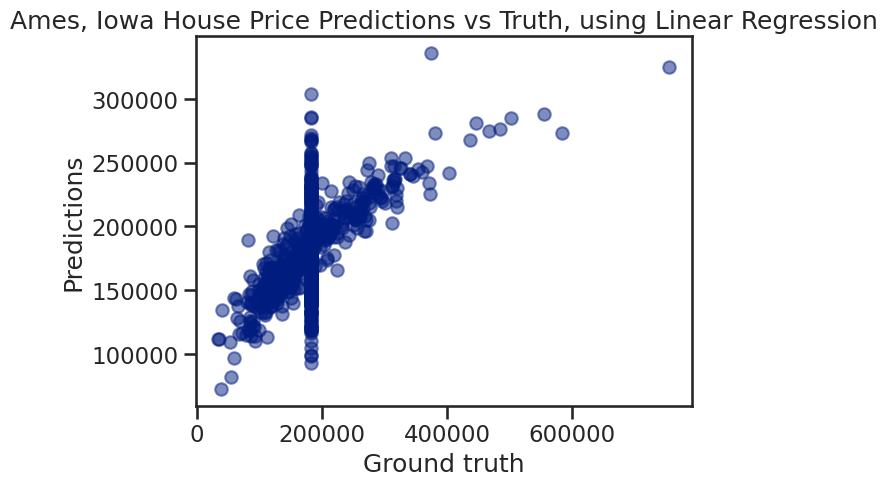

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('dark')

ax = plt.axes()
# we are going to use y_test, y_test_pred
ax.scatter(y_test, y_test_pred, alpha=.5)

ax.set(xlabel='Ground truth',
       ylabel='Predictions',
       title='Ames, Iowa House Price Predictions vs Truth, using Linear Regression');